<a href="https://colab.research.google.com/github/Sxmxxrth/AI_StockMarketPrediction/blob/main/nifty_50_unsupervised_analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install statsmodels pandas_datareader matplotlib pandas numpy==1.26.4 yfinance pandas-ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pandas-ta to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of pandas-ta to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
Requested yfinance from https://files.pythonhosted.org/packages/f3/23/0e28fa29eba03f33d74c58296f301064930340622be34b008ed02d4486de/yfinance-0.1.91-py2.py3-none-any.whl has invalid metadata: Expected matching RIGHT_PARENTHESIS for LEFT_PARENTHESIS, after version specifier
    appdirs (>=1.4.4cryptography>=3.3.2)
            ~~~~~~~~~~^
Please use pip<24.1 if you need to use this

In [ ]:
import pandas as pd
import yfinance as yf
import datetime as dt
import numpy as np
import pandas_ta
import pandas_datareader.data as web
from statsmodels.regression.rolling import RollingOLS
import statsmodels.api as sm
# Fetch Nifty 50 symbols (scrape from Wikipedia or hardcode the list above)
nifty50 = pd.read_html('https://en.wikipedia.org/wiki/NIFTY_50')[1]
nifty50
symbols_list = nifty50['Symbol'].unique().tolist()
symbols_list = [symbol + '.NS' for symbol in symbols_list]  # Add .NS suffix for Yahoo Finance

end_date = dt.datetime.now() # current time or set in order'2025-08-18'
start_date = (pd.to_datetime(end_date) - pd.DateOffset(365 * 8)).strftime('%Y-%m-%d')

# Download with auto_adjust=False to ensure 'Adj Close' is included
df = yf.download(tickers=symbols_list, start=start_date, end=end_date, auto_adjust=False).stack()
df.index.names = ['date', 'ticker']
df.columns = df.columns.str.lower()

df

ModuleNotFoundError: No module named 'pandas_ta'

# 2. Calculate features and technical indicators for each stock.

*   Garman-Klass Volatility
*   RSI
*   Bollinger Bands
*   ATR
*   Dollar Volume


In [ ]:
# Calculate features and technical indicators for each stock.
# Garman-Klass Volatility
# RSI
# Bollinger Bands
# ATR
# MACD
# Dollar Volume

df['gkv']=((np.log(df['high'])-np.log(df['low']))**2)/2-(2*np.log(2)-1)*((np.log(df['adj close'])-np.log(df['open']))**2)
df['rsi']=df.groupby(level = 1)['adj close'].transform(lambda x:pandas_ta.rsi(close=x,length=20))
df['bb_low']=df.groupby(level = 1)['adj close'].transform(lambda x:pandas_ta.bbands(close=np.log1p(x),length=30).iloc[:,0])
df['bb_mid']=df.groupby(level = 1)['adj close'].transform(lambda x:pandas_ta.bbands(close=np.log1p(x),length=30).iloc[:,1])
df['bb_high']=df.groupby(level = 1)['adj close'].transform(lambda x:pandas_ta.bbands(close=np.log1p(x),length=30).iloc[:,2])


# ATR
def compute_atr(stock_data):
    atr = pandas_ta.atr(
        high=stock_data['high'],
        low=stock_data['low'],
        close=stock_data['close'],
        length=14
    )
    return (atr - atr.mean()) / atr.std()   # normalized ATR

df['atr'] = df.groupby(level=1, group_keys=False).apply(compute_atr)

# MACD
def compute_macd(stock_data):
    macd = pandas_ta.macd(close=stock_data['adj close'], length=20).iloc[:,0]
    return (macd - macd.mean()) / macd.std()

df['macd'] = df.groupby(level=1, group_keys=False).apply(compute_macd)

# Rupee Volume
df['rupee_volume'] = (df['adj close'] * df['volume']) / 1e6

df

Price                        adj close         close          high  \
date       ticker                                                    
2017-08-24 ADANIENT.NS       58.532688     59.475967     60.429546   
           ADANIPORTS.NS    362.867493    380.049988    387.649994   
           APOLLOHOSP.NS   1052.114258   1083.199951   1099.449951   
           ASIANPAINT.NS   1063.902222   1135.599976   1145.000000   
           AXISBANK.NS      504.116425    506.850006    510.500000   
...                                ...           ...           ...   
2025-08-21 TECHM.NS        1521.300049   1521.300049   1531.699951   
           TITAN.NS        3616.300049   3616.300049   3625.000000   
           TRENT.NS        5452.500000   5452.500000   5547.000000   
           ULTRACEMCO.NS  12870.000000  12870.000000  12906.000000   
           WIPRO.NS         249.910004    249.910004    252.740005   

Price                              low          open     volume       gkv  \
date       ticker                                                           
2017-08-24 ADANIENT.NS       58.903824     60.320564  8056806.0 -0.000023   
           ADANIPORTS.NS    379.000000    386.950012  2507753.0 -0.001340   
           APOLLOHOSP.NS   1073.599976   1093.000000   399263.0 -0.000278   
           ASIANPAINT.NS   1131.000000   1140.400024   483362.0 -0.001787   
           AXISBANK.NS      502.049988    503.000000  7157375.0  0.000137   
...                                ...           ...        ...       ...   
2025-08-21 TECHM.NS        1509.099976   1528.000000  1251760.0  0.000103   
           TITAN.NS        3588.199951   3595.000000   673486.0  0.000039   
           TRENT.NS        5439.000000   5457.000000   607314.0  0.000193   
           ULTRACEMCO.NS  12790.000000  12890.000000   155457.0  0.000040   
           WIPRO.NS         249.610001    252.740005  7607486.0  0.000029   

Price                           rsi    bb_low    bb_mid   bb_high       atr  \
date       ticker                                                             
2017-08-24 ADANIENT.NS          NaN       NaN       NaN       NaN       NaN   
           ADANIPORTS.NS        NaN       NaN       NaN       NaN       NaN   
           APOLLOHOSP.NS        NaN       NaN       NaN       NaN       NaN   
           ASIANPAINT.NS        NaN       NaN       NaN       NaN       NaN   
           AXISBANK.NS          NaN       NaN       NaN       NaN       NaN   
...                             ...       ...       ...       ...       ...   
2025-08-21 TECHM.NS       49.885411  7.256386  7.320572  7.384758  0.565385   
           TITAN.NS       62.858191  8.103760  8.144316  8.184872  0.420846   
           TRENT.NS       51.603768  8.519454  8.576786  8.634119  1.079055   
           ULTRACEMCO.NS  66.666524  9.392991  9.424899  9.456806  0.867935   
           WIPRO.NS       50.274691  5.474911  5.523644  5.572377  0.174033   

Price                         macd  rupee_volume  
date       ticker                                 
2017-08-24 ADANIENT.NS         NaN    471.586513  
           ADANIPORTS.NS       NaN    909.982043  
           APOLLOHOSP.NS       NaN    420.070295  
           ASIANPAINT.NS       NaN    514.249906  
           AXISBANK.NS         NaN   3608.150294  
...                            ...           ...  
2025-08-21 TECHM.NS      -0.745698   1904.302549  
           TITAN.NS       0.534833   2435.527455  
           TRENT.NS      -0.087780   3311.379585  
           ULTRACEMCO.NS  1.248315   2000.731590  
           WIPRO.NS      -0.542670   1901.186854  

[95301 rows x 14 columns]

<Axes: xlabel='date'>

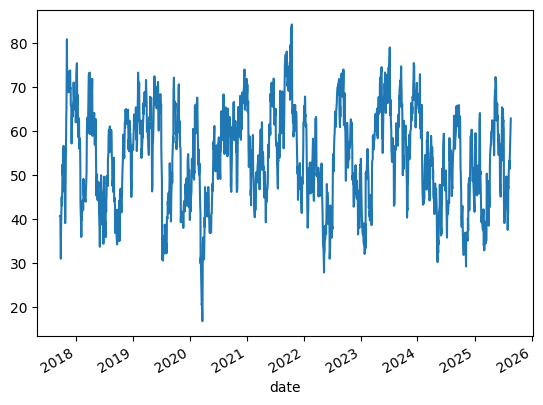

In [ ]:
# ploting the rsi of titan share
df.xs('TITAN.NS',level = 1)['rsi'].plot()

# 3. Calculate the top 8 most liquid stocks for each month.

*   To reduct the training time and experiment with Features and stregies , we convert the businees-daily to month-end frequncy


In [ ]:
df.unstack('ticker')['rupee_volume'].resample('M').mean().stack('ticker').to_frame('rupee_volume')

/tmp/ipython-input-3810164569.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.unstack('ticker')['rupee_volume'].resample('M').mean().stack('ticker').to_frame('rupee_volume')


rupee_volume
date       ticker                     
2017-08-31 ADANIENT.NS     1738.446709
           ADANIPORTS.NS   1102.418012
           APOLLOHOSP.NS    398.012789
           ASIANPAINT.NS    783.828584
           AXISBANK.NS     2272.350039
...                                ...
2025-08-31 TECHM.NS        2524.147992
           TITAN.NS        2603.145171
           TRENT.NS        6174.826514
           ULTRACEMCO.NS   3473.201284
           WIPRO.NS        1752.059513

[4681 rows x 1 columns]

In [ ]:

last_cols = [c for c in df.columns.unique(0) if c not in ['rupee_volume','volume','high','low','open','close']]
last_cols

data=pd.concat([df.unstack('ticker')['rupee_volume'].resample('M').mean().stack('ticker').to_frame('rupee_volume'),df.unstack()[last_cols].resample('M').last().stack('ticker')],axis=1).dropna()
data

/tmp/ipython-input-1640461948.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data=pd.concat([df.unstack('ticker')['rupee_volume'].resample('M').mean().stack('ticker').to_frame('rupee_volume'),df.unstack()[last_cols].resample('M').last().stack('ticker')],axis=1).dropna()
/tmp/ipython-input-1640461948.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data=pd.concat([df.unstack('ticker')['rupee_volume'].resample('M').mean().stack('ticker').to_frame('rupee_volume'),df.unstack()[last_cols].resample('M').last().stack('ticker')],axis=1).dropna()
/tmp/ipython-input-1640461948.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  data=pd.concat([df.unstack('ticker')['rupee_

rupee_volume     adj close       gkv        rsi  \
date       ticker                                                           
2017-10-31 ADANIENT.NS      531.054068     70.947090  0.000171  60.814955   
           ADANIPORTS.NS   1259.143032    410.893311 -0.000672  69.148871   
           APOLLOHOSP.NS    279.300908   1014.286987 -0.000095  45.240021   
           ASIANPAINT.NS    694.844296   1108.780029 -0.001522  50.830417   
           AXISBANK.NS     6952.371707    520.328613  0.001479  57.714864   
...                                ...           ...       ...        ...   
2025-08-31 TECHM.NS        2524.147992   1521.300049  0.000103  49.885411   
           TITAN.NS        2603.145171   3616.300049  0.000039  62.858191   
           TRENT.NS        6174.826514   5452.500000  0.000193  51.603768   
           ULTRACEMCO.NS   3473.201284  12870.000000  0.000040  66.666524   
           WIPRO.NS        1752.059513    249.910004  0.000029  50.274691   

                            bb_low    bb_mid   bb_high       atr      macd  
date       ticker                                                           
2017-10-31 ADANIENT.NS    4.104202  4.201441  4.298679 -1.031261 -0.103808  
           ADANIPORTS.NS  5.874656  5.950116  6.025575 -1.007801  0.265214  
           APOLLOHOSP.NS  6.883359  6.932431  6.981502 -1.491474 -0.437959  
           ASIANPAINT.NS  6.957206  7.010768  7.064329 -1.440614 -0.110775  
           AXISBANK.NS    6.124231  6.213228  6.302225 -0.710467 -0.425974  
...                            ...       ...       ...       ...       ...  
2025-08-31 TECHM.NS       7.256386  7.320572  7.384758  0.565385 -0.745698  
           TITAN.NS       8.103760  8.144316  8.184872  0.420846  0.534833  
           TRENT.NS       8.519454  8.576786  8.634119  1.079055 -0.087780  
           ULTRACEMCO.NS  9.392991  9.424899  9.456806  0.867935  1.248315  
           WIPRO.NS       5.474911  5.523644  5.572377  0.174033 -0.542670  

[4584 rows x 9 columns]

In [ ]:
# lets find 4 year rolling avg of rupee volume

data['rupee_volume'] = (
    data['rupee_volume']
    .unstack('ticker')
    .rolling(4*12, min_periods=1).mean()
    .stack()
)
data = data.dropna(subset=['rupee_volume'])

data['rupee_volume_rank']=(data.groupby('date')['rupee_volume'].rank(ascending=False))

data=data[data['rupee_volume_rank']<=8].drop(['rupee_volume','rupee_volume_rank'],axis=1)

data

adj close       gkv        rsi    bb_low  \
date       ticker                                                      
2017-10-31 AXISBANK.NS     520.328613  0.001479  57.714864  6.124231   
           BHARTIARTL.NS   427.195618  0.000143  68.534010  5.679925   
           HDFCBANK.NS     847.895691 -0.001660  49.211522  6.719676   
           ICICIBANK.NS    288.257568 -0.000506  60.627853  5.504927   
           INFY.NS         383.321594 -0.013562  55.444627  5.900481   
...                               ...       ...        ...       ...   
2025-08-31 ICICIBANK.NS   1446.000000  0.000025  54.045138  7.241406   
           INFY.NS        1496.400024  0.000102  47.448280  7.235070   
           RELIANCE.NS    1424.800049  0.000033  52.144780  7.198362   
           SBIN.NS         825.700012  0.000056  58.104333  6.673638   
           TATAMOTORS.NS   685.400024  0.000044  53.044770  6.462187   

                            bb_mid   bb_high       atr      macd  
date       ticker                                                 
2017-10-31 AXISBANK.NS    6.213228  6.302225 -0.710467 -0.425974  
           BHARTIARTL.NS  5.900404  6.120883 -0.505667  1.304804  
           HDFCBANK.NS    6.750423  6.781170 -1.257028 -0.155381  
           ICICIBANK.NS   5.595160  5.685394 -0.889815 -0.093533  
           INFY.NS        5.935754  5.971027 -1.843763 -0.030179  
...                            ...       ...       ...       ...  
2025-08-31 ICICIBANK.NS   7.272849  7.304291  0.324138 -0.473131  
           INFY.NS        7.319671  7.404273  0.276046 -1.338073  
           RELIANCE.NS    7.255255  7.312149  0.299056 -0.773949  
           SBIN.NS        6.702783  6.731929 -0.336463  0.381101  
           TATAMOTORS.NS  6.513559  6.564931  0.440400 -0.054676  

[760 rows x 8 columns]

# 4. Calculate monthly returns for different time horizons as features

* To capture time series dynamics that reflect, for example, momentum patterns, we compute historical returns using the method .pct_change(lag), that is, returns over various monthly periods as identified by lags


In [ ]:
t = df.xs('MARUTI.NS',level=1)
t
outlier_cutoff =0.005

lags = [1,2,3,6,9,12] #(1,2,3,6,9,12 months)

for lag in lags:
  t[f'return_{lag}m']=(t['adj close'].pct_change(lag).pipe(lambda x:x.clip(lower = x.quantile(outlier_cutoff),upper = x.quantile(1-outlier_cutoff))).add(1).pow(1/lag).sub(1))

t

/tmp/ipython-input-2258708912.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t[f'return_{lag}m']=(t['adj close'].pct_change(lag).pipe(lambda x:x.clip(lower = x.quantile(outlier_cutoff),upper = x.quantile(1-outlier_cutoff))).add(1).pow(1/lag).sub(1))
/tmp/ipython-input-2258708912.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t[f'return_{lag}m']=(t['adj close'].pct_change(lag).pipe(lambda x:x.clip(lower = x.quantile(outlier_cutoff),upper = x.quantile(1-outlier_cutoff))).add(1).pow(1/lag).sub(1))
/t

Price,adj close,close,high,low,open,volume,gkv,rsi,bb_low,bb_mid,bb_high,atr,macd,rupee_volume,return_1m,return_2m,return_3m,return_6m,return_9m,return_12m
date,,,,,,,,,,,,,,,,,,,,
2017-08-24,7069.086426,7612.850098,7635.000000,7483.600098,7536.000000,436912.0,-0.001380,NaN,NaN,NaN,NaN,NaN,NaN,3088.568688,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-28,7037.654297,7579.000000,7649.000000,7568.049805,7649.000000,391028.0,-0.002624,NaN,NaN,NaN,NaN,NaN,NaN,2751.919884,-0.004446,NaN,NaN,NaN,NaN,NaN
2017-08-29,6984.261230,7521.500000,7575.549805,7495.049805,7565.000000,368309.0,-0.002407,NaN,NaN,NaN,NaN,NaN,NaN,2572.366270,-0.007587,-0.006018,NaN,NaN,NaN,NaN
2017-08-30,7017.644531,7557.450195,7639.350098,7532.500000,7603.000000,471048.0,-0.002380,NaN,NaN,NaN,NaN,NaN,NaN,3305.647421,0.004780,-0.001423,-0.002432,NaN,NaN,NaN
2017-08-31,7150.289551,7700.299805,7720.399902,7532.000000,7564.899902,586954.0,-0.000922,NaN,NaN,NaN,NaN,NaN,NaN,4196.891053,0.018902,0.011816,0.005307,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-14,12936.000000,12936.000000,12956.000000,12825.000000,12864.000000,318580.0,0.000040,63.045540,9.402663,9.430210,9.457757,0.310663,0.647771,4121.150880,0.007948,0.003731,0.008891,0.005409,0.005599,0.003969
2025-08-18,14068.000000,14068.000000,14125.000000,13664.000000,13703.000000,2154781.0,0.000284,77.556727,9.382504,9.434121,9.485737,1.553269,1.394977,30313.459108,0.065167,0.044470,0.030914,0.018107,0.014440,0.010012
2025-08-19,14250.000000,14250.000000,14270.000000,13979.000000,14070.000000,906623.0,0.000150,78.955285,9.369269,9.438793,9.508318,1.560192,2.065737,12919.377750,0.012937,0.044470,0.032484,0.020857,0.014332,0.011161


In [ ]:
def calculate_returns(df):
  outlier_cutoff =0.005

  lags = [1,2,3,6,9,12] #(1,2,3,6,9,12 months)

  for lag in lags:
    df[f'return_{lag}m']=(df['adj close'].pct_change(lag).pipe(lambda x:x.clip(lower = x.quantile(outlier_cutoff),upper = x.quantile(1-outlier_cutoff))).add(1).pow(1/lag).sub(1))
  return df

data = data.groupby(level=1,group_keys=False).apply(calculate_returns).dropna()
data




adj close       gkv        rsi    bb_low  \
date       ticker                                                      
2018-10-31 AXISBANK.NS     579.258972  0.001058  49.767158  6.288778   
           ICICIBANK.NS    342.514801  0.000803  62.942934  5.657411   
           INFY.NS         586.482178 -0.004966  50.562382  6.300743   
           MARUTI.NS      6198.416504 -0.002137  31.175382  8.671078   
           RELIANCE.NS     471.920746 -0.000093  41.578733  6.097358   
...                               ...       ...        ...       ...   
2025-08-31 ICICIBANK.NS   1446.000000  0.000025  54.045138  7.241406   
           INFY.NS        1496.400024  0.000102  47.448280  7.235070   
           RELIANCE.NS    1424.800049  0.000033  52.144780  7.198362   
           SBIN.NS         825.700012  0.000056  58.104333  6.673638   
           TATAMOTORS.NS   685.400024  0.000044  53.044770  6.462187   

                            bb_mid   bb_high       atr      macd  return_1m  \
date       ticker                                                             
2018-10-31 AXISBANK.NS    6.362865  6.436951  0.707521 -0.750493  -0.050306   
           ICICIBANK.NS   5.730820  5.804230 -0.290460  0.192067   0.161840   
           INFY.NS        6.381808  6.462874 -0.358403 -0.664760  -0.049552   
           MARUTI.NS      8.819254  8.967430  0.899910 -2.395549  -0.099558   
           RELIANCE.NS    6.228835  6.360311 -0.284622 -1.180140  -0.156365   
...                            ...       ...       ...       ...        ...   
2025-08-31 ICICIBANK.NS   7.272849  7.304291  0.324138 -0.473131  -0.016365   
           INFY.NS        7.319671  7.404273  0.276046 -1.338073  -0.008350   
           RELIANCE.NS    7.255255  7.312149  0.299056 -0.773949   0.028982   
           SBIN.NS        6.702783  6.731929 -0.336463  0.381101   0.036595   
           TATAMOTORS.NS  6.513559  6.564931  0.440400 -0.054676   0.029206   

                          return_2m  return_3m  return_6m  return_9m  \
date       ticker                                                      
2018-10-31 AXISBANK.NS    -0.052881   0.019016   0.019952  -0.002114   
           ICICIBANK.NS    0.017936   0.054334   0.038540   0.001140   
           INFY.NS        -0.018685   0.005500   0.027366   0.022916   
           MARUTI.NS      -0.147143  -0.111616  -0.045284  -0.038560   
           RELIANCE.NS    -0.075495  -0.036368   0.017400   0.011800   
...                             ...        ...        ...        ...   
2025-08-31 ICICIBANK.NS    0.003920   0.002612   0.032303   0.012752   
           INFY.NS        -0.033460  -0.014347  -0.017566  -0.022236   
           RELIANCE.NS    -0.023640   0.002245   0.029701   0.011361   
           SBIN.NS         0.003256   0.005469   0.034095   0.000440   
           TATAMOTORS.NS  -0.001891  -0.013242   0.018128  -0.014227   

                          return_12m  
date       ticker                     
2018-10-31 AXISBANK.NS      0.008981  
           ICICIBANK.NS     0.014475  
           INFY.NS          0.036074  
           MARUTI.NS       -0.017111  
           RELIANCE.NS      0.010646  
...                              ...  
2025-08-31 ICICIBANK.NS     0.014278  
           INFY.NS         -0.019494  
           RELIANCE.NS     -0.004477  
           SBIN.NS          0.002686  
           TATAMOTORS.NS   -0.038791  

[618 rows x 14 columns]

# 5. Download Fama-French Factors and Calculate Rolling Factor Betas.

* We will introduce the Fama—French data to estimate the exposure of assets to common risk factors using linear regression.

* The five Fama—French factors, namely market risk, size, value, operating profitability, and investment have been shown empirically to explain asset returns and are commonly used to assess the risk/return profile of portfolios. Hence, it is natural to include past factor exposures as financial features in models.

* We can access the historical factor returns using the pandas-datareader and estimate historical exposures using the RollingOLS rolling linear regression.

In [ ]:
factor_data =web.DataReader('F-F_Research_Data_5_Factors_2x3','famafrench',start=2010)[0].drop('RF',axis=1)
factor_data.index=factor_data.index.to_timestamp()
factor_data=factor_data.resample('M').last().div(100)
factor_data.index.name = 'date'
factor_data

/tmp/ipython-input-2487503369.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  factor_data =web.DataReader('F-F_Research_Data_5_Factors_2x3','famafrench',start=2010)[0].drop('RF',axis=1)
/tmp/ipython-input-2487503369.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  factor_data =web.DataReader('F-F_Research_Data_5_Factors_2x3','famafrench',start=2010)[0].drop('RF',axis=1)
/tmp/ipython-input-2487503369.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  factor_data=factor_data.resample('M').last().div(100)


,Mkt-RF,SMB,HML,RMW,CMA
date,,,,,
2010-01-31,-0.0335,0.0040,0.0033,-0.0108,0.0051
2010-02-28,0.0339,0.0149,0.0318,-0.0029,0.0142
2010-03-31,0.0630,0.0183,0.0219,-0.0061,0.0174
2010-04-30,0.0200,0.0496,0.0296,0.0061,0.0175
2010-05-31,-0.0790,0.0008,-0.0248,0.0130,-0.0024
...,...,...,...,...,...
2025-02-28,-0.0243,-0.0491,0.0491,0.0110,0.0306
2025-03-31,-0.0639,-0.0149,0.0290,0.0211,-0.0047
2025-04-30,-0.0084,-0.0186,-0.0340,-0.0285,-0.0267


In [ ]:
factor_data=factor_data.join(data['return_1m'])
factor_data.xs('MARUTI.NS',level=1).head()

,Mkt-RF,SMB,HML,RMW,CMA,return_1m
date,,,,,,
2018-10-31,-0.0764,-0.0438,0.0338,0.0103,0.0360,-0.099558
2018-11-30,0.0171,-0.0081,0.0036,-0.0061,0.0040,0.157971
2018-12-31,-0.0955,-0.0281,-0.0192,-0.0003,0.0024,-0.025595
2019-01-31,0.0836,0.0291,-0.0039,-0.0073,-0.0165,-0.110421
2019-02-28,0.0342,0.0172,-0.0266,0.0016,-0.0154,0.028391


In [ ]:
factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                          
2018-10-31 AXISBANK.NS   -0.0764 -0.0438  0.0338  0.0103  0.0360  -0.050306
           ICICIBANK.NS  -0.0764 -0.0438  0.0338  0.0103  0.0360   0.161840
           INFY.NS       -0.0764 -0.0438  0.0338  0.0103  0.0360  -0.049552
           MARUTI.NS     -0.0764 -0.0438  0.0338  0.0103  0.0360  -0.099558
           RELIANCE.NS   -0.0764 -0.0438  0.0338  0.0103  0.0360  -0.156365
...                          ...     ...     ...     ...     ...        ...
2025-06-30 ICICIBANK.NS   0.0486 -0.0002 -0.0160 -0.0319  0.0145   0.000000
           INFY.NS        0.0486 -0.0002 -0.0160 -0.0319  0.0145   0.025021
           RELIANCE.NS    0.0486 -0.0002 -0.0160 -0.0319  0.0145   0.056091
           SBIN.NS        0.0486 -0.0002 -0.0160 -0.0319  0.0145   0.009910
           TATAMOTORS.NS  0.0486 -0.0002 -0.0160 -0.0319  0.0145  -0.035559

[604 rows x 6 columns]

In [ ]:
observations=factor_data.groupby(level=1).size()

valid_stocks = observations[observations>=10]
factor_Data = factor_data[factor_data.index.get_level_values('ticker').isin(valid_stocks.index)]
factor_Data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                          
2018-10-31 AXISBANK.NS   -0.0764 -0.0438  0.0338  0.0103  0.0360  -0.050306
           ICICIBANK.NS  -0.0764 -0.0438  0.0338  0.0103  0.0360   0.161840
           INFY.NS       -0.0764 -0.0438  0.0338  0.0103  0.0360  -0.049552
           MARUTI.NS     -0.0764 -0.0438  0.0338  0.0103  0.0360  -0.099558
           RELIANCE.NS   -0.0764 -0.0438  0.0338  0.0103  0.0360  -0.156365
...                          ...     ...     ...     ...     ...        ...
2025-06-30 ICICIBANK.NS   0.0486 -0.0002 -0.0160 -0.0319  0.0145   0.000000
           INFY.NS        0.0486 -0.0002 -0.0160 -0.0319  0.0145   0.025021
           RELIANCE.NS    0.0486 -0.0002 -0.0160 -0.0319  0.0145   0.056091
           SBIN.NS        0.0486 -0.0002 -0.0160 -0.0319  0.0145   0.009910
           TATAMOTORS.NS  0.0486 -0.0002 -0.0160 -0.0319  0.0145  -0.035559

[604 rows x 6 columns]

In [ ]:

betas = (factor_data.groupby(level=1,
                            group_keys=False)
         .apply(lambda x: RollingOLS(endog=x['return_1m'],
                                     exog=sm.add_constant(x.drop('return_1m', axis=1)),
                                     window=min(24, x.shape[0]),
                                     min_nobs=len(x.columns)+1)
         .fit(params_only=True)
         .params
         .drop('const', axis=1)))

betas

Mkt-RF       SMB       HML       RMW       CMA
date       ticker                                                         
2018-10-31 AXISBANK.NS         NaN       NaN       NaN       NaN       NaN
           ICICIBANK.NS        NaN       NaN       NaN       NaN       NaN
           INFY.NS             NaN       NaN       NaN       NaN       NaN
           MARUTI.NS           NaN       NaN       NaN       NaN       NaN
           RELIANCE.NS         NaN       NaN       NaN       NaN       NaN
...                            ...       ...       ...       ...       ...
2025-06-30 ICICIBANK.NS  -0.311967  0.314706 -0.206116 -0.547638  0.286617
           INFY.NS        0.230624  0.710689 -0.380989 -0.100566  0.117378
           RELIANCE.NS    0.247855 -0.378645  0.154842 -1.055374 -0.386957
           SBIN.NS       -0.511365  1.295841 -0.680245 -0.661904  0.181025
           TATAMOTORS.NS  0.540914  0.477596  0.505978  0.550625 -0.090855

[604 rows x 5 columns]

In [ ]:
data=data.join(betas.groupby('ticker').shift())
data

adj close       gkv        rsi    bb_low  \
date       ticker                                                      
2018-10-31 AXISBANK.NS     579.258972  0.001058  49.767158  6.288778   
           ICICIBANK.NS    342.514801  0.000803  62.942934  5.657411   
           INFY.NS         586.482178 -0.004966  50.562382  6.300743   
           MARUTI.NS      6198.416504 -0.002137  31.175382  8.671078   
           RELIANCE.NS     471.920746 -0.000093  41.578733  6.097358   
...                               ...       ...        ...       ...   
2025-08-31 ICICIBANK.NS   1446.000000  0.000025  54.045138  7.241406   
           INFY.NS        1496.400024  0.000102  47.448280  7.235070   
           RELIANCE.NS    1424.800049  0.000033  52.144780  7.198362   
           SBIN.NS         825.700012  0.000056  58.104333  6.673638   
           TATAMOTORS.NS   685.400024  0.000044  53.044770  6.462187   

                            bb_mid   bb_high       atr      macd  return_1m  \
date       ticker                                                             
2018-10-31 AXISBANK.NS    6.362865  6.436951  0.707521 -0.750493  -0.050306   
           ICICIBANK.NS   5.730820  5.804230 -0.290460  0.192067   0.161840   
           INFY.NS        6.381808  6.462874 -0.358403 -0.664760  -0.049552   
           MARUTI.NS      8.819254  8.967430  0.899910 -2.395549  -0.099558   
           RELIANCE.NS    6.228835  6.360311 -0.284622 -1.180140  -0.156365   
...                            ...       ...       ...       ...        ...   
2025-08-31 ICICIBANK.NS   7.272849  7.304291  0.324138 -0.473131  -0.016365   
           INFY.NS        7.319671  7.404273  0.276046 -1.338073  -0.008350   
           RELIANCE.NS    7.255255  7.312149  0.299056 -0.773949   0.028982   
           SBIN.NS        6.702783  6.731929 -0.336463  0.381101   0.036595   
           TATAMOTORS.NS  6.513559  6.564931  0.440400 -0.054676   0.029206   

                          return_2m  return_3m  return_6m  return_9m  \
date       ticker                                                      
2018-10-31 AXISBANK.NS    -0.052881   0.019016   0.019952  -0.002114   
           ICICIBANK.NS    0.017936   0.054334   0.038540   0.001140   
           INFY.NS        -0.018685   0.005500   0.027366   0.022916   
           MARUTI.NS      -0.147143  -0.111616  -0.045284  -0.038560   
           RELIANCE.NS    -0.075495  -0.036368   0.017400   0.011800   
...                             ...        ...        ...        ...   
2025-08-31 ICICIBANK.NS    0.003920   0.002612   0.032303   0.012752   
           INFY.NS        -0.033460  -0.014347  -0.017566  -0.022236   
           RELIANCE.NS    -0.023640   0.002245   0.029701   0.011361   
           SBIN.NS         0.003256   0.005469   0.034095   0.000440   
           TATAMOTORS.NS  -0.001891  -0.013242   0.018128  -0.014227   

                          return_12m  Mkt-RF  SMB  HML  RMW  CMA  
date       ticker                                                 
2018-10-31 AXISBANK.NS      0.008981     NaN  NaN  NaN  NaN  NaN  
           ICICIBANK.NS     0.014475     NaN  NaN  NaN  NaN  NaN  
           INFY.NS          0.036074     NaN  NaN  NaN  NaN  NaN  
           MARUTI.NS       -0.017111     NaN  NaN  NaN  NaN  NaN  
           RELIANCE.NS      0.010646     NaN  NaN  NaN  NaN  NaN  
...                              ...     ...  ...  ...  ...  ...  
2025-08-31 ICICIBANK.NS     0.014278     NaN  NaN  NaN  NaN  NaN  
           INFY.NS         -0.019494     NaN  NaN  NaN  NaN  NaN  
           RELIANCE.NS     -0.004477     NaN  NaN  NaN  NaN  NaN  
           SBIN.NS          0.002686     NaN  NaN  NaN  NaN  NaN  
           TATAMOTORS.NS   -0.038791     NaN  NaN  NaN  NaN  NaN  

[618 rows x 19 columns]

In [ ]:
factors=['Mkt-RF','SMB','HML','RMW','CMA']
data.loc[:,factors] =data.groupby('ticker',group_keys=False)[factors].apply(lambda x:x.fillna(x.mean()))
data.info()

data = data.drop('adj close',axis=1)
data = data.dropna()
data

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 618 entries, (Timestamp('2018-10-31 00:00:00'), 'AXISBANK.NS') to (Timestamp('2025-08-31 00:00:00'), 'TATAMOTORS.NS')
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   adj close   618 non-null    float64
 1   gkv         618 non-null    float64
 2   rsi         618 non-null    float64
 3   bb_low      618 non-null    float64
 4   bb_mid      618 non-null    float64
 5   bb_high     618 non-null    float64
 6   atr         618 non-null    float64
 7   macd        618 non-null    float64
 8   return_1m   618 non-null    float64
 9   return_2m   618 non-null    float64
 10  return_3m   618 non-null    float64
 11  return_6m   618 non-null    float64
 12  return_9m   618 non-null    float64
 13  return_12m  618 non-null    float64
 14  Mkt-RF      618 non-null    float64
 15  SMB         618 non-null    float64
 16  HML         618 non-null    float64
 17  RMW         618

gkv        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                             
2018-10-31 AXISBANK.NS    0.001058  49.767158  6.288778  6.362865  6.436951   
           ICICIBANK.NS   0.000803  62.942934  5.657411  5.730820  5.804230   
           INFY.NS       -0.004966  50.562382  6.300743  6.381808  6.462874   
           MARUTI.NS     -0.002137  31.175382  8.671078  8.819254  8.967430   
           RELIANCE.NS   -0.000093  41.578733  6.097358  6.228835  6.360311   
...                            ...        ...       ...       ...       ...   
2025-08-31 ICICIBANK.NS   0.000025  54.045138  7.241406  7.272849  7.304291   
           INFY.NS        0.000102  47.448280  7.235070  7.319671  7.404273   
           RELIANCE.NS    0.000033  52.144780  7.198362  7.255255  7.312149   
           SBIN.NS        0.000056  58.104333  6.673638  6.702783  6.731929   
           TATAMOTORS.NS  0.000044  53.044770  6.462187  6.513559  6.564931   

                               atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                               
2018-10-31 AXISBANK.NS    0.707521 -0.750493  -0.050306  -0.052881   0.019016   
           ICICIBANK.NS  -0.290460  0.192067   0.161840   0.017936   0.054334   
           INFY.NS       -0.358403 -0.664760  -0.049552  -0.018685   0.005500   
           MARUTI.NS      0.899910 -2.395549  -0.099558  -0.147143  -0.111616   
           RELIANCE.NS   -0.284622 -1.180140  -0.156365  -0.075495  -0.036368   
...                            ...       ...        ...        ...        ...   
2025-08-31 ICICIBANK.NS   0.324138 -0.473131  -0.016365   0.003920   0.002612   
           INFY.NS        0.276046 -1.338073  -0.008350  -0.033460  -0.014347   
           RELIANCE.NS    0.299056 -0.773949   0.028982  -0.023640   0.002245   
           SBIN.NS       -0.336463  0.381101   0.036595   0.003256   0.005469   
           TATAMOTORS.NS  0.440400 -0.054676   0.029206  -0.001891  -0.013242   

                          return_6m  return_9m  return_12m    Mkt-RF  \
date       ticker                                                      
2018-10-31 AXISBANK.NS     0.019952  -0.002114    0.008981  0.708512   
           ICICIBANK.NS    0.038540   0.001140    0.014475  0.597109   
           INFY.NS         0.027366   0.022916    0.036074  1.574876   
           MARUTI.NS      -0.045284  -0.038560   -0.017111  0.213799   
           RELIANCE.NS     0.017400   0.011800    0.010646  0.554057   
...                             ...        ...         ...       ...   
2025-08-31 ICICIBANK.NS    0.032303   0.012752    0.014278  0.597109   
           INFY.NS        -0.017566  -0.022236   -0.019494  1.574876   
           RELIANCE.NS     0.029701   0.011361   -0.004477  0.554057   
           SBIN.NS         0.034095   0.000440    0.002686  0.501865   
           TATAMOTORS.NS   0.018128  -0.014227   -0.038791  0.938805   

                               SMB       HML       RMW       CMA  
date       ticker                                                 
2018-10-31 AXISBANK.NS    0.053403  0.524954 -0.335567  0.005419  
           ICICIBANK.NS  -0.159478  0.620735 -0.251991 -0.316388  
           INFY.NS       -0.434510 -0.813524 -2.353089  2.209910  
           MARUTI.NS      1.390665  0.036458  3.329924  0.306317  
           RELIANCE.NS   -0.472351  0.217518 -0.413657  0.043114  
...                            ...       ...       ...       ...  
2025-08-31 ICICIBANK.NS  -0.159478  0.620735 -0.251991 -0.316388  
           INFY.NS       -0.434510 -0.813524 -2.353089  2.209910  
           RELIANCE.NS   -0.472351  0.217518 -0.413657  0.043114  
           SBIN.NS        0.016589  0.757892 -0.793606 -0.103611  
           TATAMOTORS.NS -0.207221  0.539578 -0.270202 -0.616707  

[618 rows x 18 columns]

# 6. For each month fit a K-Means Clustering Algorithm to group similar assets based on their features.
* K-Means Clustering
You may want to initialize predefined centroids for each cluster based on your research.

* For visualization purpose of this tutorial we will initially rely on the ‘k-means++’ initialization.

* Then we will pre-define our centroids for each cluster.

In [ ]:
data = data.drop('cluster', axis=1)


In [ ]:
from sklearn.cluster import KMeans

target_rsi_values = [30, 50, 70]
initial_centroids = np.zeros((len(target_rsi_values), 18))
initial_centroids[:, 6] = target_rsi_values
initial_centroids

#data = data.drop('cluster', axis=1)

def get_clusters(df):
    df['cluster'] = KMeans(n_clusters=3,
                           random_state=0,
                           init=initial_centroids).fit(df).labels_
    return df

data = data.dropna().groupby('date', group_keys=False).apply(get_clusters)

data

gkv        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                             
2018-10-31 AXISBANK.NS    0.001058  49.767158  6.288778  6.362865  6.436951   
           ICICIBANK.NS   0.000803  62.942934  5.657411  5.730820  5.804230   
           INFY.NS       -0.004966  50.562382  6.300743  6.381808  6.462874   
           MARUTI.NS     -0.002137  31.175382  8.671078  8.819254  8.967430   
           RELIANCE.NS   -0.000093  41.578733  6.097358  6.228835  6.360311   
...                            ...        ...       ...       ...       ...   
2025-08-31 ICICIBANK.NS   0.000025  54.045138  7.241406  7.272849  7.304291   
           INFY.NS        0.000102  47.448280  7.235070  7.319671  7.404273   
           RELIANCE.NS    0.000033  52.144780  7.198362  7.255255  7.312149   
           SBIN.NS        0.000056  58.104333  6.673638  6.702783  6.731929   
           TATAMOTORS.NS  0.000044  53.044770  6.462187  6.513559  6.564931   

                               atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                               
2018-10-31 AXISBANK.NS    0.707521 -0.750493  -0.050306  -0.052881   0.019016   
           ICICIBANK.NS  -0.290460  0.192067   0.161840   0.017936   0.054334   
           INFY.NS       -0.358403 -0.664760  -0.049552  -0.018685   0.005500   
           MARUTI.NS      0.899910 -2.395549  -0.099558  -0.147143  -0.111616   
           RELIANCE.NS   -0.284622 -1.180140  -0.156365  -0.075495  -0.036368   
...                            ...       ...        ...        ...        ...   
2025-08-31 ICICIBANK.NS   0.324138 -0.473131  -0.016365   0.003920   0.002612   
           INFY.NS        0.276046 -1.338073  -0.008350  -0.033460  -0.014347   
           RELIANCE.NS    0.299056 -0.773949   0.028982  -0.023640   0.002245   
           SBIN.NS       -0.336463  0.381101   0.036595   0.003256   0.005469   
           TATAMOTORS.NS  0.440400 -0.054676   0.029206  -0.001891  -0.013242   

                          return_6m  return_9m  return_12m    Mkt-RF  \
date       ticker                                                      
2018-10-31 AXISBANK.NS     0.019952  -0.002114    0.008981  0.708512   
           ICICIBANK.NS    0.038540   0.001140    0.014475  0.597109   
           INFY.NS         0.027366   0.022916    0.036074  1.574876   
           MARUTI.NS      -0.045284  -0.038560   -0.017111  0.213799   
           RELIANCE.NS     0.017400   0.011800    0.010646  0.554057   
...                             ...        ...         ...       ...   
2025-08-31 ICICIBANK.NS    0.032303   0.012752    0.014278  0.597109   
           INFY.NS        -0.017566  -0.022236   -0.019494  1.574876   
           RELIANCE.NS     0.029701   0.011361   -0.004477  0.554057   
           SBIN.NS         0.034095   0.000440    0.002686  0.501865   
           TATAMOTORS.NS   0.018128  -0.014227   -0.038791  0.938805   

                               SMB       HML       RMW       CMA  cluster  
date       ticker                                                          
2018-10-31 AXISBANK.NS    0.053403  0.524954 -0.335567  0.005419        2  
           ICICIBANK.NS  -0.159478  0.620735 -0.251991 -0.316388        1  
           INFY.NS       -0.434510 -0.813524 -2.353089  2.209910        2  
           MARUTI.NS      1.390665  0.036458  3.329924  0.306317        0  
           RELIANCE.NS   -0.472351  0.217518 -0.413657  0.043114        0  
...                            ...       ...       ...       ...      ...  
2025-08-31 ICICIBANK.NS  -0.159478  0.620735 -0.251991 -0.316388        2  
           INFY.NS       -0.434510 -0.813524 -2.353089  2.209910        0  
           RELIANCE.NS   -0.472351  0.217518 -0.413657  0.043114        2  
           SBIN.NS        0.016589  0.757892 -0.793606 -0.103611        1  
           TATAMOTORS.NS -0.207221  0.539578 -0.270202 -0.616707        2  

[618 rows x 19 columns]

In [ ]:
import matplotlib.pyplot as plt
def plot_clusters(data):
    cluster_0 = data[data['cluster']==0]
    cluster_1 = data[data['cluster']==1]
    cluster_2 = data[data['cluster']==2]

    plt.scatter(cluster_0['gkv'], cluster_0['rsi'], color='red', label='cluster 0')
    plt.scatter(cluster_1['gkv'], cluster_1['rsi'], color='green', label='cluster 1')
    plt.scatter(cluster_2['gkv'], cluster_2['rsi'], color='blue', label='cluster 2')

    plt.xlabel("gkv")
    plt.ylabel("RSI")
    plt.legend()
    plt.show()


cluster_summary = data.groupby(['date', 'cluster'])['rsi'].mean().unstack()
print(cluster_summary.head())



cluster             0          1          2
date                                       
2018-10-31  36.377057  62.942934  51.781353
2018-11-30  51.882449  55.940406  55.783470
2018-12-31  49.578024  57.593392  55.407260
2019-01-31  45.967819  69.772987  64.035773
2019-02-28  44.102063  58.496718  52.751993


In [ ]:
rsi_target = 70

# Identify which cluster is closest to 70 each month
rsi_cluster_map = data.groupby(['date','cluster'])['rsi'].mean().unstack()
chosen_cluster = (rsi_cluster_map - rsi_target).abs().idxmin(axis=1)


# 7. For each month select assets based on the cluster and form a portfolio based on Efficient Frontier max sharpe ratio optimization
* First we will filter only stocks corresponding to the cluster we choose based on our hypothesis.

* Momentum is persistent and my idea would be that stocks clustered around RSI 70 centroid should continue to outperform in the following month - thus I would select stocks corresponding to cluster 3.

In [ ]:
!pip install --upgrade pip
!pip install pyportfolioopt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pyportfolioopt]


In [ ]:
import yfinance as yf
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models, expected_returns
import numpy as np
import pandas as pd

In [ ]:
# 1) Pick the momentum cluster → RSI ≈ 70
filtered_df = data[data['cluster']==2].copy()  # adjust if cluster 2 is RSI~70
filtered_df = filtered_df.reset_index(level=1)
filtered_df.index = filtered_df.index + pd.DateOffset(1)
filtered_df = filtered_df.reset_index().set_index(['date', 'ticker'])

# dictionary: {month_start : list of tickers in cluster}
dates = filtered_df.index.get_level_values('date').unique().tolist()
fixed_dates = {}
for d in dates:
    fixed_dates[d.strftime('%Y-%m-%d')] = filtered_df.xs(d, level=0).index.tolist()
fixed_dates

{'2018-11-01': ['AXISBANK.NS', 'INFY.NS', 'SBIN.NS'],
 '2018-12-01': ['AXISBANK.NS', 'ICICIBANK.NS', 'RELIANCE.NS'],
 '2019-01-01': ['ICICIBANK.NS'],
 '2019-02-01': ['INFY.NS', 'RELIANCE.NS'],
 '2019-03-01': ['INFY.NS', 'RELIANCE.NS'],
 '2019-04-01': ['ICICIBANK.NS', 'RELIANCE.NS'],
 '2019-05-01': ['AXISBANK.NS',
  'ICICIBANK.NS',
  'INFY.NS',
  'RELIANCE.NS',
  'SBIN.NS'],
 '2019-06-01': ['ICICIBANK.NS', 'TCS.NS'],
 '2019-07-01': ['AXISBANK.NS', 'TCS.NS'],
 '2019-08-01': ['ICICIBANK.NS', 'TCS.NS'],
 '2019-09-01': ['ICICIBANK.NS', 'MARUTI.NS', 'RELIANCE.NS', 'TCS.NS'],
 '2019-10-01': ['HDFCBANK.NS', 'RELIANCE.NS'],
 '2019-11-01': ['AXISBANK.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'SBIN.NS'],
 '2019-12-01': ['ICICIBANK.NS', 'SBIN.NS'],
 '2020-01-01': ['MARUTI.NS'],
 '2020-02-01': ['AXISBANK.NS', 'ICICIBANK.NS', 'SBIN.NS'],
 '2020-03-01': ['AXISBANK.NS', 'INFY.NS'],
 '2020-04-01': ['INFY.NS'],
 '2020-05-01': ['TCS.NS'],
 '2020-06-01': ['HDFCBANK.NS', 'RELIANCE.NS', 'TCS.NS'],
 '2020-07-01': 

In [ ]:

# 2) Download fresh price data for all NIFTY50 stocks in your dataset
stocks = data.index.get_level_values('ticker').unique().tolist()

new_df = yf.download(
    tickers=stocks,
    start=data.index.get_level_values('date').unique()[0] - pd.DateOffset(months=12),
    end=data.index.get_level_values('date').unique()[-1],auto_adjust =False
)


[*********************100%***********************]  10 of 10 completed


In [ ]:
new_df['Volume']

Ticker,AXISBANK.NS,BAJFINANCE.NS,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,MARUTI.NS,RELIANCE.NS,SBIN.NS,TATAMOTORS.NS,TCS.NS
Date,,,,,,,,,,
2017-10-31,39655956,7648830,2341230,19050731,9954988,318652,9504986,16455750,6214996,1592634
2017-11-01,22542766,4689990,2095306,38829935,5633134,631375,17571371,34907283,7310931,741882
2017-11-02,7800191,4586030,2368972,27736221,4686138,247753,10277678,23110527,8262211,1468422
2017-11-03,9303981,7699950,1905244,14258432,3699086,288916,4798537,26898400,8116263,666886
2017-11-06,8013536,5830970,3074122,16349376,5066534,392588,9757496,17143407,19456789,1377000
...,...,...,...,...,...,...,...,...,...,...
2025-08-18,7964987,16277779,9642398,6908844,7254561,2154781,11785109,6138124,14226172,2945609
2025-08-19,5661531,5764382,6176219,6709554,3986094,906623,14384719,5076681,19440384,2650784
2025-08-20,3034728,5561646,4975114,5817858,10413061,391425,8725641,4493888,10050137,4952358


In [ ]:
new_df['Adj Close']

Ticker,AXISBANK.NS,BAJFINANCE.NS,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,MARUTI.NS,RELIANCE.NS,SBIN.NS,TATAMOTORS.NS,TCS.NS
Date,,,,,,,,,,
2017-10-31,520.328552,175.604996,847.895691,288.257538,383.321594,7624.745117,415.602661,282.166718,422.125732,1166.917603
2017-11-01,532.214050,176.204773,853.849915,301.032715,385.483795,7649.955566,420.770844,295.130920,431.338776,1157.511719
2017-11-02,529.280029,176.541245,854.271851,304.154449,383.758240,7638.255371,418.142578,290.055969,428.530579,1167.873657
2017-11-03,537.187073,179.150055,858.303833,303.434082,385.317566,7632.312988,417.568329,299.882904,441.143066,1165.182983
2017-11-06,531.617310,177.692032,857.319275,303.626160,386.169983,7716.626465,411.914154,303.573730,456.120483,1185.395142
...,...,...,...,...,...,...,...,...,...,...
2025-08-18,1082.599976,905.200012,2003.599976,1434.599976,1435.800049,14068.000000,1381.699951,827.650024,676.000000,3011.199951
2025-08-19,1083.199951,902.299988,1991.099976,1436.300049,1440.000000,14250.000000,1420.099976,830.400024,700.250000,3016.199951
2025-08-20,1080.199951,887.799988,1988.199951,1430.599976,1496.199951,14221.000000,1413.000000,828.950012,689.599976,3098.600098


In [ ]:
# 3) Calculate daily returns
returns_dataframe = np.log(new_df['Adj Close']).diff()
returns_dataframe

Ticker,AXISBANK.NS,BAJFINANCE.NS,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,MARUTI.NS,RELIANCE.NS,SBIN.NS,TATAMOTORS.NS,TCS.NS
Date,,,,,,,,,,
2017-10-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-11-01,0.022585,0.003410,0.006998,0.043365,0.005625,0.003301,0.012359,0.044921,0.021591,-0.008093
2017-11-02,-0.005528,0.001908,0.000494,0.010317,-0.004486,-0.001531,-0.006266,-0.017345,-0.006532,0.008912
2017-11-03,0.014829,0.014669,0.004709,-0.002371,0.004055,-0.000778,-0.001374,0.033318,0.029007,-0.002307
2017-11-06,-0.010423,-0.008172,-0.001148,0.000633,0.002210,0.010986,-0.013633,0.012232,0.033388,0.017198
...,...,...,...,...,...,...,...,...,...,...
2025-08-18,0.013391,0.049539,0.006258,0.005101,-0.008254,0.083889,0.005734,0.001330,0.017008,-0.003679
2025-08-19,0.000554,-0.003209,-0.006258,0.001184,0.002921,0.012854,0.027413,0.003317,0.035244,0.001659
2025-08-20,-0.002773,-0.016201,-0.001458,-0.003976,0.038285,-0.002037,-0.005012,-0.001748,-0.015326,0.026953


In [ ]:
# 4) Portfolio construction loop (robust + safe)
portfolio_df = pd.DataFrame()

def optimize_weights(prices, lower_bound=0, upper_bound=0.3):
    """Try Max Sharpe optimization, fallback to Min Volatility if infeasible."""
    mu = expected_returns.mean_historical_return(prices=prices, frequency=252)
    cov = risk_models.sample_cov(prices=prices, frequency=252)

    ef = EfficientFrontier(mu, cov, weight_bounds=(lower_bound, upper_bound), solver="SCS")
    try:
        weights = ef.max_sharpe()
    except Exception:
        weights = ef.min_volatility()
    return ef.clean_weights()


def nsei_scalping_strategy(prices, short_window=5, long_window=20):
    """
    Example scalping logic:
    - Generate intramonth signals using short/long SMA cross.
    - Output monthly aggregated return.
    """
    df = prices.copy()

    # Simple fast vs slow SMA crossover
    df['SMA_short'] = df['Adj Close'].rolling(short_window).mean()
    df['SMA_long']  = df['Adj Close'].rolling(long_window).mean()

    # Buy when short > long, else flat (0)
    df['Signal'] = np.where(df['SMA_short'] > df['SMA_long'], 1, 0)

    # Daily returns
    df['Return'] = df['Adj Close'].pct_change()

    # Strategy return
    df['Strat'] = df['Signal'].shift(1) * df['Return']

    return df['Strat']


for start_date in fixed_dates.keys():
    try:
        end_date = (pd.to_datetime(start_date) + pd.offsets.MonthEnd(0)).strftime('%Y-%m-%d')
        cols = fixed_dates[start_date]

        # 12M training window
        optimization_start_date = (pd.to_datetime(start_date) - pd.DateOffset(months=12)).strftime('%Y-%m-%d')
        optimization_end_date   = (pd.to_datetime(start_date) - pd.DateOffset(days=1)).strftime('%Y-%m-%d')
        optimization_df = new_df['Adj Close'][optimization_start_date:optimization_end_date][cols]

        print(f"\n===== {start_date} =====")
        print(f"Optimization df shape: {optimization_df.shape}")
        print(f"Optimization df columns: {optimization_df.columns.tolist()}")

        # === CASE 1: NSEI Scalping only ===
        if len(cols) == 1 and ("NSEI" in cols[0] or "^NSEI" in cols[0]):
            print("⚡ NSEI Scalping mode active")
            temp_df = new_df.loc[start_date:end_date, ['Adj Close']].rename(columns={'Adj Close': 'NSEI'})
            strat_returns = nsei_scalping_strategy(temp_df)
            strat_returns = strat_returns.to_frame(name="Strategy Return")

        # === CASE 2: Normal portfolio optimization ===
        else:
            if optimization_df.shape[1] < 2 or optimization_df.empty:
                print(f"Not enough assets for {start_date}, fallback to Equal Weights")
                weights = {col: 1/len(cols) for col in cols}
            else:
                try:
                    lower_bound = round(1/(len(optimization_df.columns)*2), 3)
                    weights = optimize_weights(
                        prices=optimization_df,
                        lower_bound=lower_bound,
                        upper_bound=0.5
                    )
                    print("Optimized Weights:", weights)
                except Exception as e:
                    print(f"⚠️ Optimization failed for {start_date}, fallback to Equal Weights")
                    print("Error:", e)
                    weights = {col: 1/len(cols) for col in cols}

            # Slice returns for the current month
            valid_start = returns_dataframe.index[returns_dataframe.index >= start_date].min()
            valid_end   = returns_dataframe.index[returns_dataframe.index <= end_date].max()

            if pd.isna(valid_start) or pd.isna(valid_end):
                print(f"⚠️ No trading days between {start_date} and {end_date}, skipping...")
                continue

            temp_df = returns_dataframe.loc[valid_start:valid_end, cols]

            if temp_df.empty:
                print(f"⚠️ Empty returns slice for {start_date}, skipping...")
                continue

            w = np.array([weights[c] for c in cols])
            weighted_returns = temp_df.values @ w
            strat_returns = pd.DataFrame(
                weighted_returns,
                index=temp_df.index,
                columns=['Strategy Return']
            )

        # Append to portfolio
        portfolio_df = pd.concat([portfolio_df, strat_returns])

    except Exception as e:
        print(f"❌ Error at {start_date}: {e}")

# Drop duplicates just in case
portfolio_df = portfolio_df.drop_duplicates()



===== 2018-11-01 =====
Optimization df shape: (248, 3)
Optimization df columns: ['AXISBANK.NS', 'INFY.NS', 'SBIN.NS']
Optimized Weights: OrderedDict({'AXISBANK.NS': 0.333, 'INFY.NS': 0.5, 'SBIN.NS': 0.167})

===== 2018-12-01 =====
Optimization df shape: (246, 3)
Optimization df columns: ['AXISBANK.NS', 'ICICIBANK.NS', 'RELIANCE.NS']
Optimized Weights: OrderedDict({'AXISBANK.NS': 0.29949, 'ICICIBANK.NS': 0.20051, 'RELIANCE.NS': 0.5})

===== 2019-01-01 =====
Optimization df shape: (246, 1)
Optimization df columns: ['ICICIBANK.NS']
Not enough assets for 2019-01-01, fallback to Equal Weights

===== 2019-02-01 =====
Optimization df shape: (247, 2)
Optimization df columns: ['INFY.NS', 'RELIANCE.NS']
Optimized Weights: OrderedDict({'INFY.NS': 0.5, 'RELIANCE.NS': 0.5})

===== 2019-03-01 =====
Optimization df shape: (247, 2)
Optimization df columns: ['INFY.NS', 'RELIANCE.NS']
Optimized Weights: OrderedDict({'INFY.NS': 0.5, 'RELIANCE.NS': 0.5})

===== 2019-04-01 =====
Optimization df shape: (24

In [ ]:
# Download NIFTY50 index
# Download NIFTY50 index with adjusted close
nifty = yf.download(
    tickers="^NSEI",
    start="2015-01-01",
    end=pd.Timestamp.today(),
    auto_adjust=False
)

# Now "Adj Close" exists
nifty_ret = np.log(nifty[['Adj Close']]).diff().dropna()
nifty_ret = nifty_ret.rename(columns={'Adj Close': 'NIFTY50 Buy&Hold'})
nifty_ret




[*********************100%***********************]  1 of 1 completed


Price,NIFTY50 Buy&Hold
Ticker,^NSEI
Date,
2015-01-05,-0.002033
2015-01-06,-0.030422
2015-01-07,-0.003112
2015-01-08,0.016221
2015-01-09,0.006042
...,...
2025-08-14,0.000485
2025-08-18,0.009924


In [ ]:
print("Portfolio index:", portfolio_df.index.names)
print("Nifty index:", nifty_ret.index.names)


Portfolio index: ['Date']
Nifty index: ['Date']


[*********************100%***********************]  1 of 1 completed


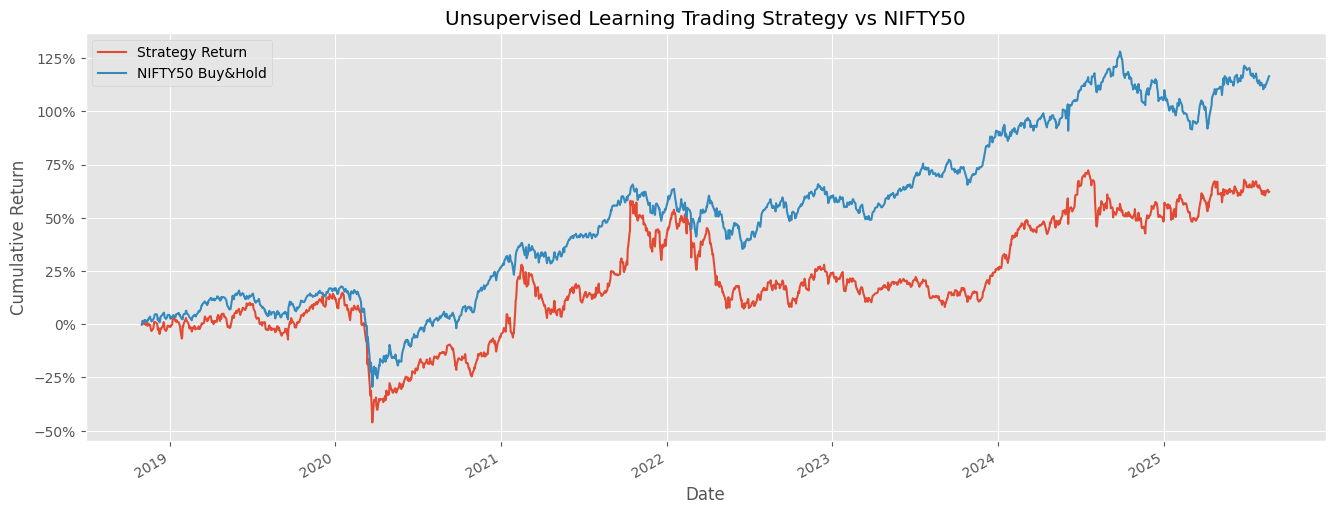

In [ ]:
# NIFTY50 download
nifty = yf.download(tickers="^NSEI", start="2015-01-01", end=pd.Timestamp.today(), auto_adjust=False)

# Compute log returns
nifty_ret = np.log(nifty[['Adj Close']]).diff().dropna()

# Flatten and rename
nifty_ret.columns = nifty_ret.columns.get_level_values(0)
nifty_ret = nifty_ret.rename(columns={'Adj Close': 'NIFTY50 Buy&Hold'})

# Merge with strategy
portfolio_df = portfolio_df.merge(nifty_ret, left_index=True, right_index=True, how="inner")

# Plot cumulative returns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.style.use('ggplot')
portfolio_cumulative_return = np.exp(np.log1p(portfolio_df).cumsum()) - 1
portfolio_cumulative_return.plot(figsize=(16,6))

plt.title("Unsupervised Learning Trading Strategy vs NIFTY50")
plt.ylabel("Cumulative Return")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.show()
